In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from PIL import Image  # For GIF creation
import os
import warnings
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from itertools import combinations
from tqdm import tqdm

import numpy as np
import pandas as pd
import skimage
import torch

import neuralpredictors

warnings.filterwarnings("ignore")

from nnfabrik.builder import get_data, get_model, get_trainer
from nnfabrik.utility.nn_helpers import set_random_seed

In [2]:
def ari_baseline(keys1, regularizer):    
    seeds=[10,42,100]
    ari_results = {}         # Stores ARI scores against ground truth
    predictions_dict = {}    

    for k1 in keys1:
        predictions_dict[k1] = {}
        cluster=k1
        for seed in seeds:
            path_ending = f'GMM_without_KL_{cluster}clusters_seed_{seed}{regularizer}'
            predictions_dict[k1][seed] = np.load(f'/user/ninasophie.nellen/sensorium/tests/predictions/predictions_{path_ending}.npy')

    ari_results = {}  

    for k1 in keys1:
        ari_results[k1] = {}  
        for seed1, seed2 in combinations(seeds, 2):
            try:
                # Check if both seeds exist before computing ARI
                if (seed1 in predictions_dict[k1]and 
                    seed2 in predictions_dict[k1]):
                    ari_score = adjusted_rand_score(
                        predictions_dict[k1][seed1], 
                        predictions_dict[k1][seed2]
                    )
                else:
                    ari_score = np.nan  
            except Exception as e:
                ari_score = np.nan  # Insert None in case of errors

            # Store result
            ari_results[k1][(seed1, seed2)] = ari_score
            #print(f"ARI between seed {seed1} and seed {seed2} for key1 {k1}: {ari_score}")


    ari_values = [list(ari_results[k1].values()) for k1 in keys1]

    # Filter out None values for mean and std calculation
    ari_means = np.array([np.mean([v for v in vals if v is not None]) if any(v is not None for v in vals) else None for vals in ari_values])
    ari_stds = np.array([np.std([v for v in vals if v is not None]) if any(v is not None for v in vals) else None for vals in ari_values])

    return ari_means, ari_stds

In [21]:
seed = 42
set_random_seed(seed)
predictions_dict = {}

regularizer = 'l1'
starting_epcoch = 1
multiplier = 1e5
exponent=2.0
clusters=20
alpha=2.1
pretrain_epoch = 10
lr_model=0.008
dim =''
seeds = [10,100,42]

for seed in seeds:
    predictions_dict[seed] = {}
    path_ending = f'KL_EM_diagcov_alpha_{alpha}_exp_{exponent}_cluster_{clusters}_mult_{multiplier}_reg_{regularizer}_pe{pretrain_epoch}_lr_{lr_model}{dim}_seed_{seed}'
    predictions_dict[seed] =torch.load(f'predictions/predictions_dec_{path_ending}.pt').cpu().numpy()

In [22]:
predictions_dict = {}
seeds = [10,100,42]
seeds = [42,101,7607]
clusters=6
for seed in seeds:
    predictions_dict[seed] = {}
    path_ending = f'{clusters}clusters_seed_{seed}_rotation_equivariant'
    predictions_dict[seed] = np.load(f'predictions/predictions_GMM_without_KL_{path_ending}.npy')

In [5]:
ari_results = {}

# Iterate over all pairs of seeds
for seed1, seed2 in combinations(predictions_dict.keys(), 2):
    ari_score = adjusted_rand_score(predictions_dict[seed1], predictions_dict[seed2])
    ari_results[(seed1, seed2)] = ari_score
    print(f"ARI for PE: {pretrain_epoch}, clusters: {clusters}, mult: {multiplier} between seed {seed1} and seed {seed2}: {ari_score:.4f}")

# Output ARI results
ari_results

ARI for PE: 10, clusters: 6, mult: 100000.0 between seed 42 and seed 101: 0.1031
ARI for PE: 10, clusters: 6, mult: 100000.0 between seed 42 and seed 7607: 0.1055
ARI for PE: 10, clusters: 6, mult: 100000.0 between seed 101 and seed 7607: 0.0970


{(42, 101): 0.10306433965244141,
 (42, 7607): 0.10550552689293437,
 (101, 7607): 0.0970056940590725}

In [ ]:
alpha=2.1
clusters = list(range(5,10)) + list(range(10, 65, 5))
# [5,10,15,20,25,30]
seeds=[10,42,100]
ari_results = {}         # Stores ARI scores against ground truth
predictions_dict = {}    # Stores predicted labels
pretrain_epochs = np.array([5,10,20,30,40])
#keys1 = np.array([5,9,10,11,20,30,40])
keys1 = np.array([1e5])
#keys1 = [1e5,1e6, 'al']
keys1 = [9,10,15, 'al']
keys2 = range(5,65,5)
lr_model = 0.008
pretrain_epoch=10
regularizer = 'l1'
multiplier = 1e5
exponent=2.0
dim = ''

for k1 in keys1:
    predictions_dict[k1] = {}
    print(k1)
    for k2 in keys2:
        predictions_dict[k1][k2] = {}
        cluster = k2
        pretrain_epoch = k1
        if multiplier == 1e6:
            lr_model = 0.007
        elif multiplier == 1e7:
            lr_model = 0.003
        elif multiplier == 1e6:
            lr_model = 0.007
        else:
            lr_model = 0.008
        '''
        if pretrain_epoch >= 20:
            lr_model= 0.003
        else:
            lr_model= 0.008
        '''
        for seed in seeds:
            
            if k1 == 'al':
                multiplier=1e5
                pretrain_epoch =10
                regularizer = 'adlognorm' 
            
            else:
                #multiplier=multiplier
                regularizer ='l1'
                #pretrain_epoch=9
            
            path_ending = f'dec_KL_EM_diagcov_alpha_{alpha}_exp_{exponent}_cluster_{cluster}_mult_{multiplier}_reg_{regularizer}_pe{pretrain_epoch}_lr_{lr_model}{dim}_seed_{seed}'
            #path_ending = f'GMM_without_KL_{cluster}clusters_seed_{seed}'
            save_path = f'predictions/predictions_{path_ending}.pt'
            if not os.path.exists(save_path):
                print(f"Warning: Model file not found for {save_path}. Inserting None.")
                predictions_dict[k1][k2][seed] = np.nan
                continue  # Skip this iteration
            #model_seed42.load_state_dict(torch.load(save_path),strict=False)
            predictions_dict[k1][k2][seed] = torch.load(f'predictions/predictions_{path_ending}.pt').cpu().numpy()

9
10
15
al


In [18]:
ari_results = {}  

for k1 in keys1:
    ari_results[k1] = {}  
    for k2 in keys2:
        ari_results[k1][k2] = {}
        for seed1, seed2 in combinations(seeds, 2):
            try:
                # Check if both seeds exist before computing ARI
                if (seed1 in predictions_dict[k1][k2] and 
                    seed2 in predictions_dict[k1][k2]):
                    
                    # Compute ARI
                    ari_score = adjusted_rand_score(
                        predictions_dict[k1][k2][seed1], 
                        predictions_dict[k1][k2][seed2]
                    )
                else:
                    ari_score = np.nan  
            except Exception as e:
                ari_score = np.nan  # Insert None in case of errors

            # Store result
            ari_results[k1][k2][(seed1, seed2)] = ari_score
            print(f"ARI between seed {seed1} and seed {seed2} for key1 {k1}, key2 {k2}: {ari_score}")


ARI between seed 10 and seed 42 for key1 9, key2 5: 0.31269731494748565
ARI between seed 10 and seed 100 for key1 9, key2 5: 0.3137716988678737
ARI between seed 42 and seed 100 for key1 9, key2 5: 0.37953231358018824
ARI between seed 10 and seed 42 for key1 9, key2 10: 0.35299552366722553
ARI between seed 10 and seed 100 for key1 9, key2 10: 0.27935378571208974
ARI between seed 42 and seed 100 for key1 9, key2 10: 0.2910038952253408
ARI between seed 10 and seed 42 for key1 9, key2 15: 0.31832332165672655
ARI between seed 10 and seed 100 for key1 9, key2 15: 0.2901079807981177
ARI between seed 42 and seed 100 for key1 9, key2 15: 0.28362607933306155
ARI between seed 10 and seed 42 for key1 9, key2 20: 0.2591806847629868
ARI between seed 10 and seed 100 for key1 9, key2 20: 0.2709277433136093
ARI between seed 42 and seed 100 for key1 9, key2 20: 0.28075219079302927
ARI between seed 10 and seed 42 for key1 9, key2 25: 0.21478112171786473
ARI between seed 10 and seed 100 for key1 9, key2 2

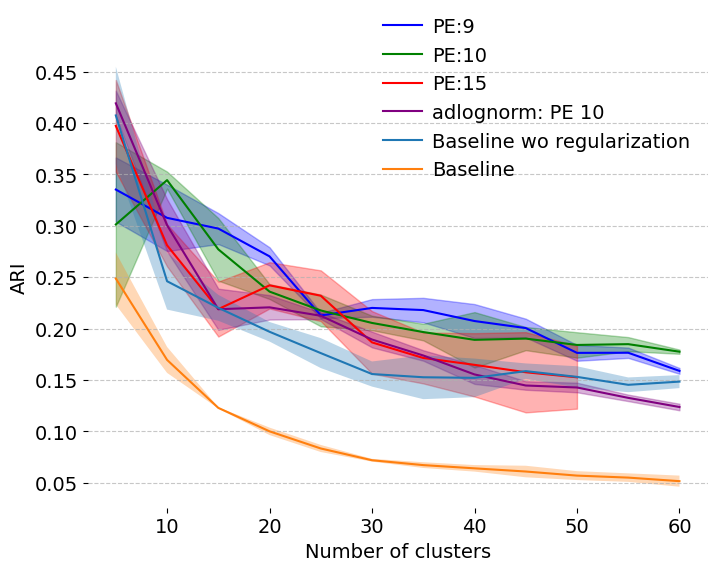

In [19]:
def plot_ARI(keys1,keys2, label1,label2, ari_results=ari_results):
    colors = [
        "blue", "green", "red", "purple", "orange", 
        "cyan", "magenta", "yellow", "brown", "pink", 'black'
    ]
    fontsize=14

    plt.figure(figsize=(8, 6))

    for i, k1 in enumerate(keys1):
        lr_model = 0.008
        #if k1 >= 20:
        #    lr_model = 0.003
        ari_values = [list(ari_results[k1][k2].values()) for k2 in keys2]

        # Filter out None values for mean and std calculation
        ari_means = np.array([np.mean([v for v in vals if v is not None]) if any(v is not None for v in vals) else None for vals in ari_values])
        ari_stds = np.array([np.std([v for v in vals if v is not None]) if any(v is not None for v in vals) else None for vals in ari_values])
        if k1 == 'al':
            plt.plot(keys2, ari_means, color=colors[i % len(colors)], label=fr"adlognorm: PE 10")
        elif label1 == r'$\beta$':
            print(k1)
            exponent = int(np.log10(k1))  # Extracts exponent from scientific notation
            plt.plot(keys2, ari_means, color=colors[i % len(colors)], label=fr"{label1}: $10^{{{exponent}}}$")
        else:
            plt.plot(keys2, ari_means, color=colors[i % len(colors)], label=f"{label1}:{k1}")
        valid_idx = [j for j, v in enumerate(ari_means) if v is not None]
        
        if valid_idx:  # Ensure there is at least one valid value
            plt.fill_between(
                np.array(keys2)[valid_idx], 
                ari_means[valid_idx] - ari_stds[valid_idx], 
                ari_means[valid_idx] + ari_stds[valid_idx], 
                color=colors[i % len(colors)], alpha=0.3
            )

    ari_means_baseline, ari_stds_baseline = ari_baseline(keys2, '_l1')
    plt.plot(keys2, ari_means_baseline,  label=f"Baseline wo regularization")

    valid_idx = [j for j, v in enumerate(ari_means_baseline) if v is not None]
    if valid_idx:  # Ensure there is at least one valid value
        plt.fill_between(
            np.array(keys2)[valid_idx], 
            ari_means_baseline[valid_idx] - ari_stds_baseline[valid_idx], 
            ari_means_baseline[valid_idx] + ari_stds_baseline[valid_idx], 
            alpha=0.3
        )

    ari_means_baseline, ari_stds_baseline = ari_baseline(keys2, '')
    plt.plot(keys2, ari_means_baseline,  label=f"Baseline")


    valid_idx = [j for j, v in enumerate(ari_means_baseline) if v is not None]
    if valid_idx:  # Ensure there is at least one valid value
        plt.fill_between(
            np.array(keys2)[valid_idx], 
            ari_means_baseline[valid_idx] - ari_stds_baseline[valid_idx], 
            ari_means_baseline[valid_idx] + ari_stds_baseline[valid_idx], 
            alpha=0.3
        )
    #ari_means_rotation_equivariant, ari_stds_rotation_equivariant = ari_baseline_from_dict(gamma_aris_lognorm_unit_01[10], keys2)
    '''
    plt.plot(keys2, ari_means_rotation_equivariant,  label=f"Rotation \nequivariant", color = 'black')
    valid_idx = [j for j, v in enumerate(ari_means_rotation_equivariant) if v is not None]
    if valid_idx:  # Ensure there is at least one valid value
        plt.fill_between(
            np.array(keys2)[valid_idx], 
            ari_means_rotation_equivariant[valid_idx] - ari_stds_rotation_equivariant[valid_idx], 
            ari_means_rotation_equivariant[valid_idx] + ari_stds_rotation_equivariant[valid_idx], 
            alpha=0.3, color = 'black'
        )
    '''
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    plt.grid(axis='y', linestyle='--', alpha=0.7)  # Only horizontal grid lines

    # Labels & Legend
    plt.xlabel(f'{label2}', fontsize=fontsize)
    plt.ylabel("ARI", fontsize=fontsize)
    plt.legend(fontsize=fontsize, frameon=False, ncol=1)
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(
        handles,
        labels,
        fontsize=fontsize,
        frameon=False,
        ncol=1,
        loc='upper right',    # Legend is anchored at upper right
        bbox_to_anchor=(1, 1.1),  # Move the legend up by increasing the y-coordinate
        columnspacing=1.5,
        handletextpad=0.5,
        borderaxespad=0.5,
        alignment='right'     # Requires matplotlib >= 3.4
    )
    plt.show()
plot_ARI(keys1,keys2, 'PE','Number of clusters', ari_results=ari_results)
#plot_ARI(keys1,keys2, r'$\beta$','Number of clusters', ari_results=ari_results)

In [9]:
import  pickle
with open(
    'Polly_data/gamma_aris_lognorm_unit_01.pkl', 
    'rb') as f:
    gamma_aris_lognorm_unit_01 = pickle.load(f)

In [10]:
def ari_baseline_from_dict(ari_dict, clusters):
    #clusters = sorted(ari_dict.keys())  # Sort cluster keys
    ari_means = []
    ari_stds = []

    for k in clusters:
        scores = [v for v in ari_dict[k] if v is not None]
        if scores:
            ari_means.append(np.mean(scores))
            ari_stds.append(np.std(scores))
        else:
            ari_means.append(None)
            ari_stds.append(None)

    return np.array(ari_means), np.array(ari_stds)

In [23]:
ari_baseline_from_dict(gamma_aris_lognorm_unit_01[10], clusters)

(array([0.35517388, 0.41067783, 0.33525944, 0.37855847, 0.37616758,
        0.31610586, 0.2563194 , 0.2468061 , 0.19779694, 0.17557679,
        0.17182488, 0.15392937, 0.15311544, 0.14648806, 0.13834469,
        0.12341715]),
 array([0.04728153, 0.02310447, 0.02878101, 0.0450224 , 0.03437599,
        0.03712782, 0.02875284, 0.01399486, 0.01227946, 0.00434975,
        0.00375855, 0.00671839, 0.00439521, 0.01054971, 0.00125081,
        0.00596593]))

{6: {(42, 101): 0.10306433965244141, (42, 7607): 0.10550552689293437, (101, 7607): 0.0970056940590725}, 7: {(42, 101): 0.09065654651440043, (42, 7607): 0.09800432377979107, (101, 7607): 0.09260461481457966}, 8: {(42, 101): 0.08761035083916337, (42, 7607): 0.09238809501085973, (101, 7607): 0.10000956290155164}, 9: {(42, 101): 0.07679089052098881, (42, 7607): 0.08156889499259175, (101, 7607): 0.08733025485091396}, 10: {(42, 101): 0.06777933183213881, (42, 7607): 0.07108340381549877, (101, 7607): 0.06985450828022721}, 11: {(42, 101): 0.06266076535865943, (42, 7607): 0.07816534049772197, (101, 7607): 0.07087183542433718}, 12: {(42, 101): 0.06443687109380125, (42, 7607): 0.07576821777593372, (101, 7607): 0.07015716074040168}, 13: {(42, 101): 0.06048733954085012, (42, 7607): 0.06966610744521838, (101, 7607): 0.05819550435011368}, 14: {(42, 101): 0.05820380354312173, (42, 7607): 0.07089242774086535, (101, 7607): 0.06197987689596751}, 15: {(42, 101): 0.056086431910895976, (42, 7607): 0.0663675

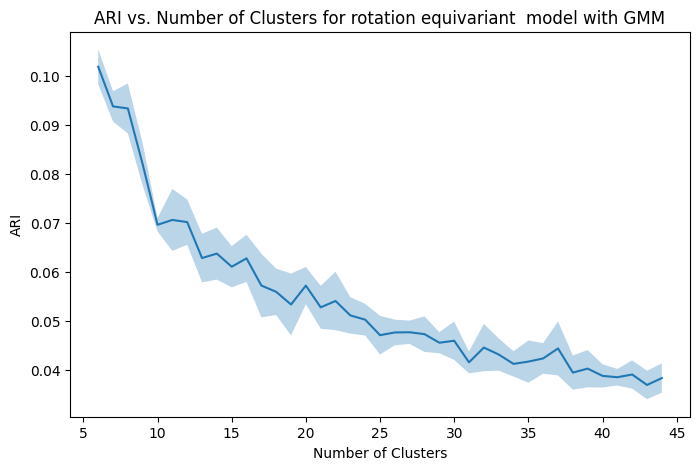

In [ ]:
alpha=2.1
clusters = list(range(5,10)) + list(range(10, 65, 5))
# [5,10,15,20,25,30]
seeds=[10,42,100]
seeds =[42,101,7607]
ari_results = {}         # Stores ARI scores against ground truth
predictions_dict = {}    # Stores predicted labels
pretrain_epochs = np.array([5,10,20,30,40])
keys1 = range(6,45)

for k1 in keys1:
    predictions_dict[k1] = {}
    cluster=k1
    for seed in seeds:
        path_ending = f'{cluster}clusters_seed_{seed}_rotation_equivariant'
        predictions_dict[k1][seed] = np.load(f'predictions/predictions_GMM_without_KL_{path_ending}.npy')

ari_results = {}  

for k1 in keys1:
    ari_results[k1] = {}  
    for seed1, seed2 in combinations(seeds, 2):
        try:
            # Check if both seeds exist before computing ARI
            if (seed1 in predictions_dict[k1]and 
                seed2 in predictions_dict[k1]):
                ari_score = adjusted_rand_score(
                    predictions_dict[k1][seed1], 
                    predictions_dict[k1][seed2]
                )
            else:
                ari_score = np.nan  
        except Exception as e:
            ari_score = np.nan  # Insert None in case of errors

        # Store result
        ari_results[k1][(seed1, seed2)] = ari_score
        #print(f"ARI between seed {seed1} and seed {seed2} for key1 {k1}: {ari_score}")

print(ari_results)
colors = ["blue", "green", "red", "purple", "orange"]  # Adjust as needed

plt.figure(figsize=(8, 5))

ari_values = [list(ari_results[k1].values()) for k1 in keys1]

# Filter out None values for mean and std calculation
ari_means = np.array([np.mean([v for v in vals if v is not None]) if any(v is not None for v in vals) else None for vals in ari_values])
ari_stds = np.array([np.std([v for v in vals if v is not None]) if any(v is not None for v in vals) else None for vals in ari_values])

plt.plot(keys1, ari_means,  label=f"Mult: {k1} lr: {lr_model}")

valid_idx = [j for j, v in enumerate(ari_means) if v is not None]
if valid_idx:  # Ensure there is at least one valid value
    plt.fill_between(
        np.array(keys1)[valid_idx], 
        ari_means[valid_idx] - ari_stds[valid_idx], 
        ari_means[valid_idx] + ari_stds[valid_idx], 
        alpha=0.3
    )

# Labels & Legend
plt.xlabel("Number of Clusters")
plt.ylabel("ARI")
#plt.legend(title="Pretrain epochs")
plt.title(f"ARI vs. Number of Clusters for rotation equivariant  model with GMM")
plt.show()